# IS4487 Week 5 - Practice Code

This notebook is designed to help you follow along with the **Week 5 Lecture and Reading**

The practice code demos are intended to give you a chance to see working code and can be a source for your lap and assignment work.  Each section contains short explanations and annotated code that reflect the steps in the reading.

### Topics for this demo:
- Univariate analysis
- Multi-variate analysis

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Demos/demo_05_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Context: Financial Risk Assesement Analytics
FinTrust Bank is a mid-sized financial institution that provides consumer loans, credit cards, and mortgages. The risk analytics team is investigating patterns in customer borrowing behavior to better understand which customers are most likely to default on their loans.

Your task is to explore the data to understand how each variable behaves in the financial risk assesment.

# What's the business problem?

# What's the analytic problem?

# What data do you need?

# Step 1: Install and Import all Necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load Dataset (replace with your own file if needed)

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/fintrust_loans.csv'  # Replace with uploaded URL or path
df = pd.read_csv(url)

# Other ways to import the dataset?




In [ ]:
/content/sample_data/README.md

# Step 3: Preview and Basic Info

In [3]:
print(df.head())

  Loan_ID  Gender  Age Married     Education EmploymentStatus  \
0  LN1000    Male   52     Yes      Graduate         Employed   
1  LN1001  Female   59      No  Not Graduate         Employed   
2  LN1002    Male   52     Yes      Graduate         Employed   
3  LN1003    Male   24      No  Not Graduate         Employed   
4  LN1004    Male   50      No  Not Graduate         Employed   

   ApplicantIncome  LoanAmount  LoanTerm  CreditScore  HasPreviousDefaults  \
0             4417     66511.0     360.0        723.0                    0   
1             3997    238234.0     120.0        612.0                    0   
2             7093     87924.0     360.0        742.0                    0   
3             3035    109184.0      60.0        663.0                    1   
4             2129    215788.0       NaN        795.0                    0   

  LoanStatus  
0  Defaulted  
1       Paid  
2       Paid  
3       Paid  
4       Paid  


# what's the target variable?

In [4]:
print(df.shape)

(200, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Loan_ID              200 non-null    object 
 1   Gender               200 non-null    object 
 2   Age                  200 non-null    int64  
 3   Married              200 non-null    object 
 4   Education            200 non-null    object 
 5   EmploymentStatus     200 non-null    object 
 6   ApplicantIncome      200 non-null    int64  
 7   LoanAmount           190 non-null    float64
 8   LoanTerm             190 non-null    float64
 9   CreditScore          190 non-null    float64
 10  HasPreviousDefaults  200 non-null    int64  
 11  LoanStatus           200 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 18.9+ KB


In [7]:
df.describe()

,Age,ApplicantIncome,LoanAmount,LoanTerm,CreditScore,HasPreviousDefaults
count,200.000000,200.000000,190.000000,190.000000,190.000000,200.000000
mean,43.545000,4905.160000,146434.378947,170.463158,656.410526,0.140000
std,12.649825,1518.019844,52186.479879,114.499307,71.299427,0.347858
min,21.000000,888.000000,-24040.000000,36.000000,447.000000,0.000000
25%,32.750000,3973.000000,108421.500000,60.000000,611.250000,0.000000
50%,45.500000,4865.000000,151791.000000,180.000000,658.000000,0.000000
75%,53.000000,5797.750000,184586.250000,240.000000,702.500000,0.000000
max,64.000000,9175.000000,267868.000000,360.000000,820.000000,1.000000


In [8]:
for column in df.columns:
    print(f"Unique values for column '{column}':")
    print(df[column].unique())
    print("\n")

Unique values for column 'Loan_ID':
['LN1000' 'LN1001' 'LN1002' 'LN1003' 'LN1004' 'LN1005' 'LN1006' 'LN1007'
 'LN1008' 'LN1009' 'LN1010' 'LN1011' 'LN1012' 'LN1013' 'LN1014' 'LN1015'
 'LN1016' 'LN1017' 'LN1018' 'LN1019' 'LN1020' 'LN1021' 'LN1022' 'LN1023'
 'LN1024' 'LN1025' 'LN1026' 'LN1027' 'LN1028' 'LN1029' 'LN1030' 'LN1031'
 'LN1032' 'LN1033' 'LN1034' 'LN1035' 'LN1036' 'LN1037' 'LN1038' 'LN1039'
 'LN1040' 'LN1041' 'LN1042' 'LN1043' 'LN1044' 'LN1045' 'LN1046' 'LN1047'
 'LN1048' 'LN1049' 'LN1050' 'LN1051' 'LN1052' 'LN1053' 'LN1054' 'LN1055'
 'LN1056' 'LN1057' 'LN1058' 'LN1059' 'LN1060' 'LN1061' 'LN1062' 'LN1063'
 'LN1064' 'LN1065' 'LN1066' 'LN1067' 'LN1068' 'LN1069' 'LN1070' 'LN1071'
 'LN1072' 'LN1073' 'LN1074' 'LN1075' 'LN1076' 'LN1077' 'LN1078' 'LN1079'
 'LN1080' 'LN1081' 'LN1082' 'LN1083' 'LN1084' 'LN1085' 'LN1086' 'LN1087'
 'LN1088' 'LN1089' 'LN1090' 'LN1091' 'LN1092' 'LN1093' 'LN1094' 'LN1095'
 'LN1096' 'LN1097' 'LN1098' 'LN1099' 'LN1100' 'LN1101' 'LN1102' 'LN1103'
 'LN1104' 'LN11

# eda step 1&2 done

# Step 4: Check for Missing Values

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Loan_ID              200 non-null    object 
 1   Gender               200 non-null    object 
 2   Age                  200 non-null    int64  
 3   Married              200 non-null    object 
 4   Education            200 non-null    object 
 5   EmploymentStatus     200 non-null    object 
 6   ApplicantIncome      200 non-null    int64  
 7   LoanAmount           190 non-null    float64
 8   LoanTerm             190 non-null    float64
 9   CreditScore          190 non-null    float64
 10  HasPreviousDefaults  200 non-null    int64  
 11  LoanStatus           200 non-null    object 
dtypes: float64(3), int64(3), object(6)
memory usage: 18.9+ KB


In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Loan_ID                 0
Gender                  0
Age                     0
Married                 0
Education               0
EmploymentStatus        0
ApplicantIncome         0
LoanAmount             10
LoanTerm               10
CreditScore            10
HasPreviousDefaults     0
LoanStatus              0
dtype: int64


In [11]:
# rows with missing values
print(df[df.isnull().any(axis=1)])

    Loan_ID  Gender  Age Married     Education EmploymentStatus  \
4    LN1004    Male   50      No  Not Graduate         Employed   
8    LN1008    Male   35      No  Not Graduate         Employed   
9    LN1009  Female   63      No  Not Graduate       Unemployed   
12   LN1012    Male   33      No  Not Graduate       Unemployed   
28   LN1028  Female   45     Yes      Graduate    Self-Employed   
29   LN1029  Female   59      No  Not Graduate         Employed   
31   LN1031    Male   21      No  Not Graduate         Employed   
47   LN1047    Male   52      No      Graduate         Employed   
48   LN1048  Female   52      No      Graduate    Self-Employed   
49   LN1049  Female   44      No      Graduate    Self-Employed   
51   LN1051  Female   32     Yes  Not Graduate       Unemployed   
52   LN1052    Male   59     Yes      Graduate    Self-Employed   
55   LN1055  Female   57      No      Graduate    Self-Employed   
70   LN1070  Female   26      No      Graduate         Employe

# How will you handle the missing data?

# Step 5: Univariate Visualization

# Start from the target variable

<Axes: xlabel='LoanStatus', ylabel='count'>

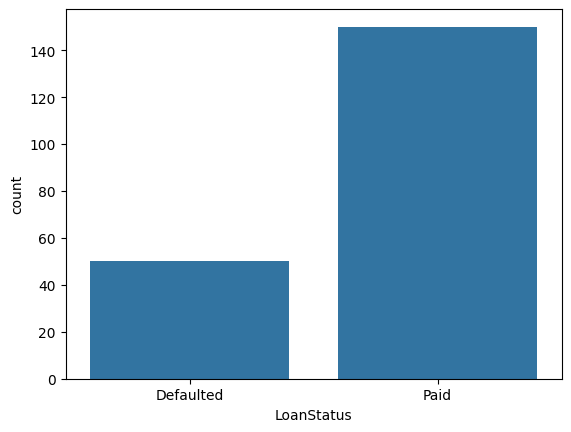

In [12]:
sns.countplot(x='LoanStatus', data=df)

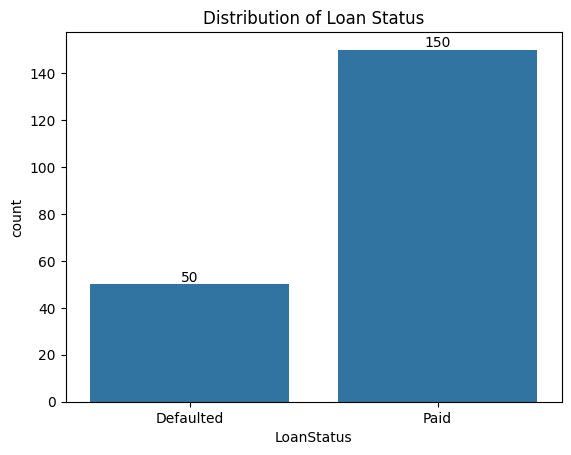

In [13]:
ax = sns.countplot(x='LoanStatus', data=df)
plt.title('Distribution of Loan Status')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

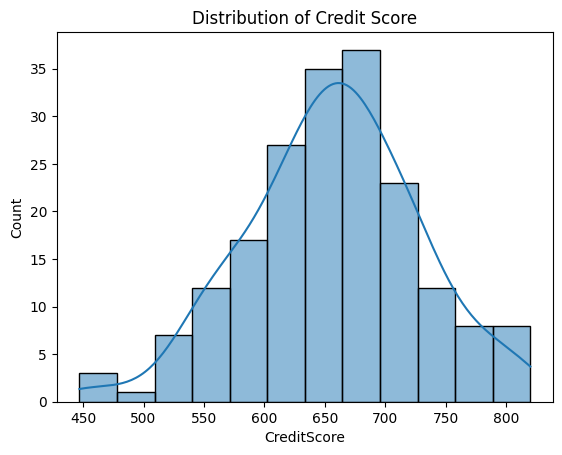

In [14]:
sns.histplot(df['CreditScore'].dropna(), kde=True)
plt.title("Distribution of Credit Score")
plt.show()

# Is it numerical or categorical?

# Skewness?

Skewness describes the asymmetry of a numeric distribution.

In [15]:
df['CreditScore'].skew()

np.float64(-0.1704833121243839)

|skew| < 0.5 → approximately symmetric

0.5 ≤ |skew| < 1 → moderately skewed

|skew| ≥ 1 → highly skewed

# Step 6: Bivariate Visualization

Numeric × Numeric

Categorical × Numeric

Categorical × Categorical


| Variable 1  | Variable 2  | Best plots         |
| ----------- | ----------- | ------------------ |
| Numeric     | Numeric     | Scatter, Line      |
| Categorical | Numeric     | Box, Violin, Bar   |
| Categorical | Categorical | Count, Stacked Bar |




# target and independent variables

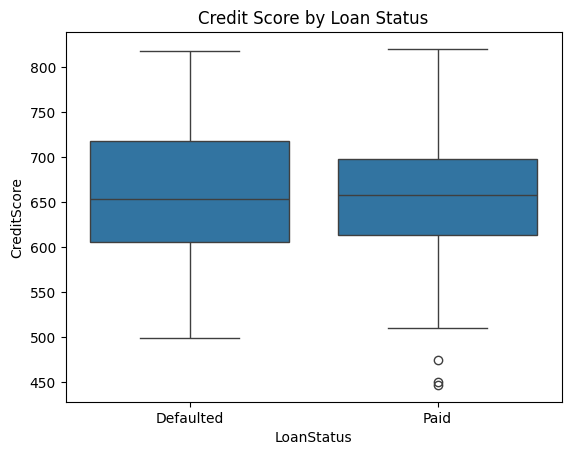

In [16]:
# Categorical x numerical types

sns.boxplot(x='LoanStatus', y='CreditScore', data=df)
plt.title("Credit Score by Loan Status")
plt.show()

# What can you observe?

median; Spread; Outliers; Overlap

Borrowers who repaid loans tend to have slightly higher credit scores, but the large overlap indicates credit score by itself is an imperfect predictor of loan default.

In [20]:
correlation = df[['LoanAmount', 'CreditScore']].corr()
print(correlation)

             LoanAmount  CreditScore
LoanAmount     1.000000    -0.035202
CreditScore   -0.035202     1.000000


# What can you observe?

|r| < 0.1 → negligible correlation

0.1 ≤ |r| < 0.3 → weak

0.3 ≤ |r| < 0.5 → moderate

≥ 0.5 → strong

There is almost no linear relationship between loan amount and credit score in this dataset.

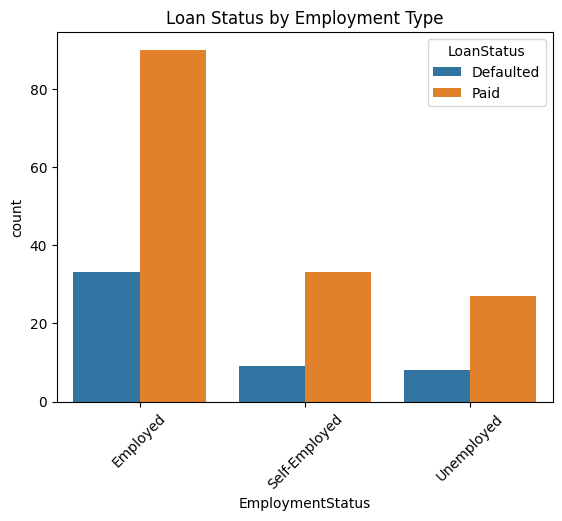

In [21]:
# Categorical × Categorical

sns.countplot(x='EmploymentStatus', hue='LoanStatus', data=df)
plt.title("Loan Status by Employment Type")
plt.xticks(rotation=45)
plt.show()

# What can you observe?

Across all employment types, paid loans exceed defaulted loans

Employment status is associated with loan outcomes

Employed applicants dominate the dataset and show better repayment outcomes

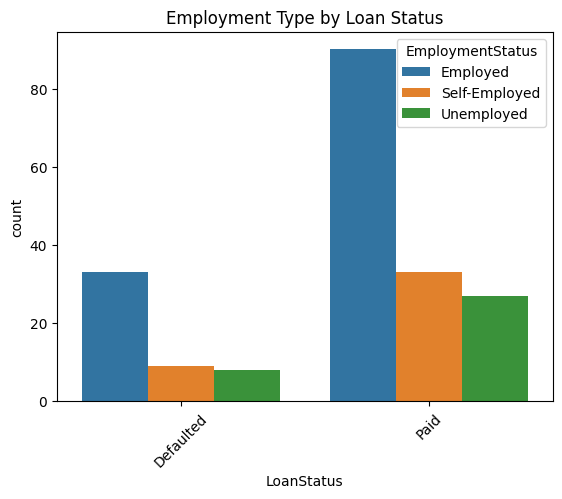

In [22]:
# Categorical × Categorical

sns.countplot(x='LoanStatus', hue='EmploymentStatus', data=df)
plt.title("Employment Type by Loan Status")
plt.xticks(rotation=45)
plt.show()

More employed defaulters -> higher risk?

# Step 7: Multivariate Visualization

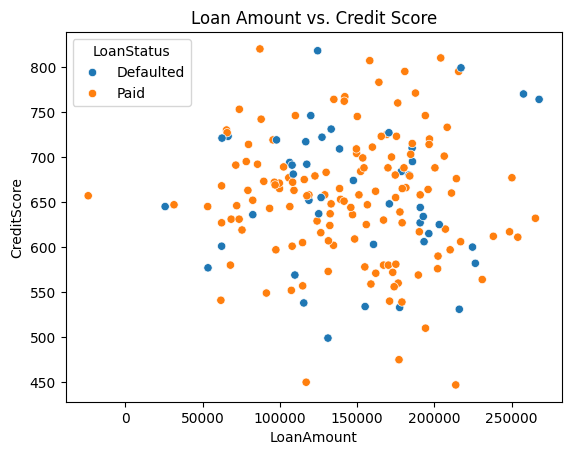

In [23]:
sns.scatterplot(x='LoanAmount', y='CreditScore', hue='LoanStatus', data=df)
plt.title("Loan Amount vs. Credit Score")
plt.show()

# What can you observe?

Relationship between Loan Amount and Credit Score?

Loan Status separation?

Credit score pattern?Loan Amount pattern?

Outliers?

# Step 7: Outlier Detection using IQR

In [24]:
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['LoanAmount'] < Q1 - 1.5 * IQR) | (df['LoanAmount'] > Q3 + 1.5 * IQR)]
print(f"\nNumber of Loan Amount Outliers: {len(outliers)}")


Number of Loan Amount Outliers: 1


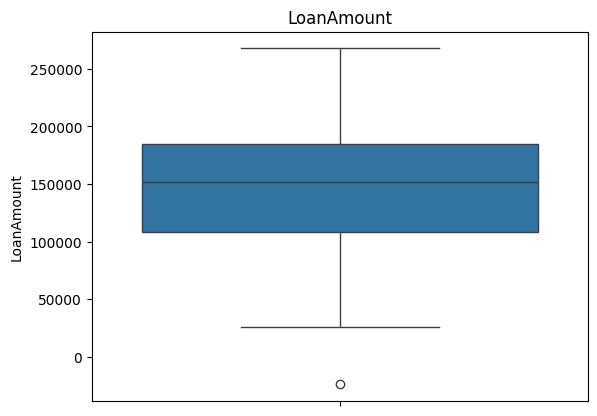

In [25]:
sns.boxplot(y='LoanAmount',data=df)
plt.title("LoanAmount")
plt.show()

In [26]:
display(outliers)

,Loan_ID,Gender,Age,Married,Education,EmploymentStatus,ApplicantIncome,LoanAmount,LoanTerm,CreditScore,HasPreviousDefaults,LoanStatus
164,LN1164,Female,50,No,Not Graduate,Self-Employed,8854,-24040.0,60.0,657.0,0,Paid


# How will you handle it?

# Step 8: Ethical Reflection Prompt

# What are the risks of using demographic data like 'Gender' or 'Marital Status' to assess default risk?

Ethical risks (Bias & fairness)

Legal & regulatory risks

Reputational risk

Demographics are often less predictive than financial metrics like Repayment history

# How can we mitigate bias in modeling?

Data-level?

Model-level?

Evaluation-level?

Post-model mitigation?

Governance & transparency?